### MC Shapley + Sobol from a Single Data Collection

The Owen & Prieur (2017) formulation for correlated-input Shapley effects
uses the cost function:

$$v(u) = \text{Cov}[f(\mathbf{X}), f(\mathbf{X}_u)]$$

where $\mathbf{X}_u$ shares the same background variables as $\mathbf{X}$
but conditions on the subset $u$.  Remarkably, this same quantity equals
the **closed Sobol index**:

$$v(u) = \mathbb{V}[\mathbb{E}(f(\mathbf{X}) \mid \mathbf{X}_u)]$$

So from the **same Monte Carlo data** used for Shapley effects, we can
extract both first-order ($S_i$) and total-order ($T_i$) Sobol indices
at zero additional cost.

$$S_i = \frac{v(\{i\})}{v(\text{full})}, \qquad
T_i = 1 - \frac{v(\text{all}\\setminus\{i\})}{v(\text{full})}$$

This notebook demonstrates the `MCShapley.compute()` method which now
returns `sobol_first` and `sobol_total` columns alongside the Shapley
effects.

We use the **Ishigami function** with correlated inputs as the test case.

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapleyx.utilities.mc_shapley import (
    GaussianCopulaUniform,
    MCShapley,
)

from importlib.metadata import version
print(f"ShapleyX v{version('shapleyx')}")

ShapleyX v0.2


In [2]:
def ishigami(x):
    """Ishigami function (1D input)."""
    return np.sin(x[0]) + 7.0 * np.sin(x[1])**2 + 0.1 * x[2]**4 * np.sin(x[0])


def ishigami_batch(X):
    """Vectorised Ishigami for batch evaluation."""
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    return np.sin(x1) + 7.0 * np.sin(x2)**2 + 0.1 * x3**4 * np.sin(x1)


d = 3
print(f"Ishigami function ready (d = {d})")

Ishigami function ready (d = 3)


---
### Correlated Input Distribution

Uniform marginals on $[-\pi, \pi]$ with $X_1$–$X_3$ correlated
($\rho = 0.8$) via a Gaussian copula.

In [3]:
corr = np.array([
    [1.0, 0.0, 0.8],
    [0.0, 1.0, 0.0],
    [0.8, 0.0, 1.0],
])

joint = GaussianCopulaUniform(
    lows=[-np.pi] * d,
    highs=[np.pi] * d,
    corr=corr,
)
print(f"GaussianCopulaUniform: d = {joint.d}")

GaussianCopulaUniform: d = 3


---
### MC Shapley + Sobol in One Call

`MCShapley.compute()` with `method='exhaustive'` now returns a DataFrame
with `sobol_first` and `sobol_total` columns — no extra model evaluations.

In [4]:
mc = MCShapley(f=ishigami, joint=joint, predict_batch=ishigami_batch)

results = mc.compute(
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    progress=True,
)
results

MC Shapley: 100%|██████████| 65000/65000 [00:00<00:00, 1738078.38evals/s]


,variable,effect,shapley_value,sobol_first,sobol_total,total_variance,lower,upper
0,X1,0.232856,2.657023,0.303621,0.196783,11.410575,0.218779,0.249578
1,X2,0.532442,6.075467,0.553070,0.546506,11.410575,0.513522,0.551245
2,X3,0.234702,2.678085,0.313939,0.190157,11.410575,0.216943,0.251340


---
### Visual Comparison: Shapley vs Sobol

For correlated inputs, the relationship between indices becomes
informative:
- **$S_i$ (first-order)**: main effect of $X_i$ alone — ignores interactions
- **Shapley**: fairly distributes interaction variance among participants
- **$T_i$ (total-order)**: effect of $X_i$ including all interactions

---
### Why $S_i > T_i$ Can Happen Under Correlation

With independent inputs, Sobol indices always satisfy
$S_i \leq T_i$ — the total effect includes interactions on top
of the main effect.  **Under correlation, this inequality no
longer holds.**

- **$S_i$ is inflated** when $X_i$ is correlated with other
  influential variables — knowing $X_i$ also tells you about them.
- **$T_i$ is deflated** when $X_{-i}$ can proxy for $X_i$ through
  correlation — $X_i$ adds little beyond what the others already
  explain.

Here $X_1$ and $X_3$ are correlated ($\rho=0.8$), so:
- $S_1$ and $S_3$ are boosted (each proxies the other)
- $T_1$ and $T_3$ are reduced (knowing $\{X_2,X_3\}$ already
  captures much of $X_1$'s influence, and vice versa)
- $X_2$ is uncorrelated, so $S_2 \approx T_2$ (as expected for
  an additive contribution)

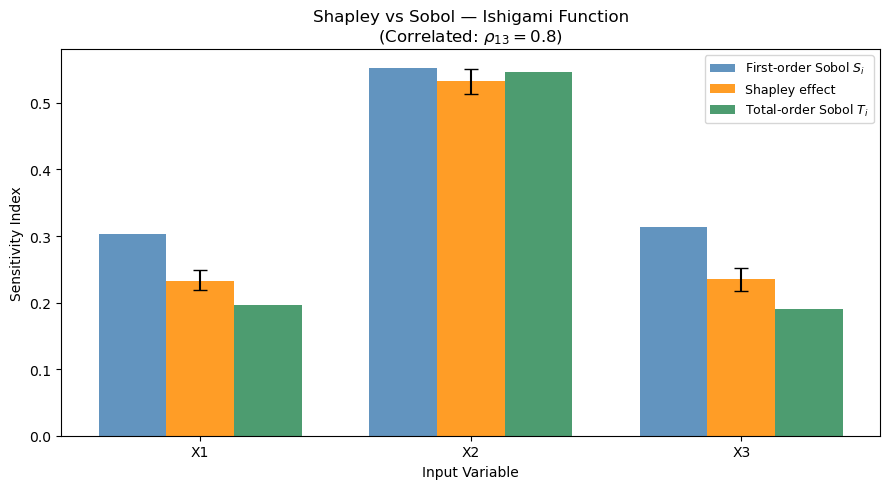

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(d)
bar_width = 0.25

ax.bar(x - bar_width, results['sobol_first'], bar_width,
       color='steelblue', alpha=0.85, label='First-order Sobol $S_i$')
ax.bar(x, results['effect'], bar_width,
       yerr=[results['effect'] - results['lower'],
             results['upper'] - results['effect']],
       capsize=5, color='darkorange', alpha=0.85, label='Shapley effect')
ax.bar(x + bar_width, results['sobol_total'], bar_width,
       color='seagreen', alpha=0.85, label='Total-order Sobol $T_i$')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Sensitivity Index')
ax.set_title('Shapley vs Sobol — Ishigami Function\n(Correlated: $\\rho_{13} = 0.8$)')
ax.set_xticks(x)
ax.set_xticklabels(results['variable'])
ax.legend(fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Interpreting the Gaps

With **independent inputs**, the usual hierarchy holds:
$S_i \leq \text{Shapley} \leq T_i$ — Shapley sits between
first-order and total-order by distributing interaction variance.

With **correlated inputs**, this breaks down because:
- Correlation inflates $S_i$ (shared information through dependence)
- Correlation deflates $T_i$ (other variables proxy for $X_i$)
- Shapley effects remain interpretable: the Shapley axioms
  (efficiency, symmetry, dummy, additivity) still hold under
  correlation, making them the preferred single-number summary.

In both panels above:
- $X_2$ (uncorrelated, additive term $7\sin^2(x_2)$) shows
  $S_2 \approx \text{Shapley}_2 \approx T_2$ — no interactions
- $X_1$ and $X_3$ differ under correlation vs independence — the
  $\rho_{13}=0.8$ correlation transfers influence between them

---
### Key Takeaways

1. **`MCShapley.compute()` now returns Sobol indices** in the same
   DataFrame — use `method='exhaustive'` for `sobol_first` and
   `sobol_total` columns.
2. **Zero additional cost** — Sobol indices are extracted from the
   same $v(u)$ values computed for Shapley effects.
3. **Shapley sits between $S_i$ and $T_i$** — it fairly distributes
   interaction variance, making it interpretable as a single-number
   summary of each input's total importance.
4. **The gaps reveal interactions** — large $(T_i - S_i)$ indicates
   strong interactions; differences under correlation also reflect
   shared information between correlated inputs.

In [6]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Sat, 02 May 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
shapleyx  : 0.2

Watermark: 2.6.0

